In [1]:
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import transforms

from torch.utils.data import TensorDataset, DataLoader

import torch
import torch.nn as nn
import torch.optim as optim

## MNIST DATAset
it use **Grayscale (1 channel)** formate  
with resolution: 28x28 pixels  
each pixel Value: ranging from **0(black)** to **255 (white)**.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(), # auto scales [0, 255] to [0.0, 1.0]
])

In [4]:
# download dataset 
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


## Make DataLoader

In [5]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

## Build CNN & RNN

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # COnvolutional Layer: Feature Extraction
        self.conv_layer = nn.Sequential(
            # 1st block: (28, 28, 1) -> (28, 28, 32) -> (14, 14, 32)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # slide small filters across the image to detect basic visual
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 2nd block: (14, 14, 32) -> (14, 14, 64) -> (7, 7, 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 3rd block: (7, 7, 64) -> (7, 7, 128) -> (3, 3, 128)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Output: (batch_size, 128, 3, 3)

            # fixed overfitting (regularization)
            nn.Dropout(0.25),
            
            # total flattened features : 3x3x128 = 1152
            # Flattens (batch_size, 128, 3, 3) => (batch_size, 1152)
            nn.Flatten()
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(in_features=128*3*3, out_features=256),
            nn.ReLU(),

            nn.Linear(in_features=256, out_features=10)
            # softmax auto apply by CrossEntopy
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

In [7]:
"""
RNN treat the image(2d) as a sequence of rows.
based on a image(28x28) pixels, RNN treats it as a sequence of 28 time steps,
where each step contains an input vector of 28 pixel features (one row)
By the time it reads the last row, its memory contains the summary of the whole image.
"""
class RNN(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=10):
        super().__init__()
        self.hidden_size=hidden_size # num of memory slots LSTM uses to track details
        self.num_layers=num_layers

        # we use LSTM (for prevents vanishing gradients problem)
        self.lstm_layer = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True, # for expects input shape: (batch_size, sequence_length, features)
            dropout=0.2
        )

        # fully connected layer for classiification
        self.fc_layer = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Dataloader provides : tensor of shape (64, 1, 28, 28)
        # Squeeze layer: reshape image from (batch_size, 1, 28, 28) to (batch_size, 28, 28), LSTMs do not understand "channels"
        # we have now 28 Time Steps (Rows), and each step contains 28 Features (Pixels in that row). 
        x = x.squeeze(1) # (batch_size, time steps, features per step),

        # Forward pass through LSTM: process 28 rows one by one
        # out -> holds the hidden state of every single row it scanned.
        # out shape: (batch_size, sequenece_length(28), hidden_size(128))
        out, _ = self.lstm_layer(x)

        # Take ONly the output from the final layer time step (index= -1)
        # which is 28th row hold the context of the entire image
        # out shape: (batch_size, 128) => a flat vector of 128 values representing the compelete summary of a image digit
        out = out[:, -1, :]
        
        out = self.fc_layer(out) # gives 10 raw scores logits.

        return out

In [8]:
cnn_model = CNN()
cnn_model = cnn_model.to(device)

rnn_model = RNN()
rnn_model = rnn_model.to(device)

### Model Output when we pass images
output shape: [256, 10] 
- 256: The number of images processed in this specific batch
- 10: The 10 possible digit classes (numbers 0 through 9)  

Each row in that tensor corresponds to one image, and it contains 10 floating-point numbers

model returns logits for every images:  
outputs (for one image) = [-1.2,  0.5,  -3.1,  6.8,  1.1,  -0.4,  -2.1,  0.2,  -1.5,  0.8] 

Higher number = The model is highly confident the image belongs to that class index.
Lower number = The model thinks it is highly unlikely to be that class.

## Define Loss function & Optimizer

In [9]:
criterian = nn.CrossEntropyLoss()  # work dirctly with raw digits, auto use Softmax

# images are not zero-centered, because we scaled input data [0.0, 1.0] 
# So take lower learning rate to ensure steady training
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

## TRain CNN Model

In [10]:
epochs = 10
cnn_train_losses = []
cnn_val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    cnn_model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        cnn_optimizer.zero_grad()

        outputs = cnn_model(images) # model return logits for all images
        # _, predicted_digits = torch.max(outputs, dim=1) # predicted_digits.shape = torch.size([256])
        loss = criterian(outputs, labels)
        loss.backward() 
        cnn_optimizer.step() # update weights

        running_train_loss += loss.item()
    
    epoch_train_loss = running_train_loss / len(train_loader)
    cnn_train_losses.append(epoch_train_loss)

    cnn_model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
        
            outputs = cnn_model(images)
            loss = criterian(outputs, labels)
            running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        cnn_val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}: train_loss={epoch_train_loss} & val_loss={epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(cnn_model.state_dict(), "best_cnn_model.pt")

epoch 1/10: train_loss=0.17660753236863136 & val_loss=0.05049442818993962
epoch 2/10: train_loss=0.05335429295396575 & val_loss=0.035437033850516886
epoch 3/10: train_loss=0.03794679652461023 & val_loss=0.032098525322948795
epoch 4/10: train_loss=0.030567539798964344 & val_loss=0.02544407137841396
epoch 5/10: train_loss=0.026186198405175557 & val_loss=0.032474202092150226
epoch 6/10: train_loss=0.021142894925720527 & val_loss=0.023822662694357722
epoch 7/10: train_loss=0.01732019265167578 & val_loss=0.026731883017169927
epoch 8/10: train_loss=0.017761463382842218 & val_loss=0.023954250965712135
epoch 9/10: train_loss=0.012490165613050148 & val_loss=0.021789267244841516
epoch 10/10: train_loss=0.012346106348781302 & val_loss=0.022477226607112565


## Train RNN Model

In [11]:
epochs = 10
rnn_train_losses = []
rnn_val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    rnn_model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        rnn_optimizer.zero_grad()
        
        outputs = rnn_model(images) # model gives: (batch_size, 10)
        # outputs = torch.softmax(outputs.squeeze())
        loss = criterian(outputs, labels)
        loss.backward() 
        rnn_optimizer.step() # update weights

        running_train_loss += loss.item()
    
    epoch_train_loss = running_train_loss / len(train_loader)
    rnn_train_losses.append(epoch_train_loss)

    rnn_model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = rnn_model(images)
            # outputs = torch.softmax(outputs.squeeze())
            loss = criterian(outputs, labels)
            running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        rnn_val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}: train_loss={epoch_train_loss} & val_loss={epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(cnn_model.state_dict(), "best_rnn_model.pt")

epoch 1/10: train_loss=0.43104737640809276 & val_loss=0.12949061253742808
epoch 2/10: train_loss=0.10723930701954977 & val_loss=0.07547434520830584
epoch 3/10: train_loss=0.06978144460315032 & val_loss=0.06162783914100331
epoch 4/10: train_loss=0.05545166873016647 & val_loss=0.06866737231048667
epoch 5/10: train_loss=0.046491539417785895 & val_loss=0.051043387451083076
epoch 6/10: train_loss=0.03632816609072396 & val_loss=0.04731706285828451
epoch 7/10: train_loss=0.03420956626139544 & val_loss=0.04700277891595089
epoch 8/10: train_loss=0.02969303416247829 & val_loss=0.047135335418646326
epoch 9/10: train_loss=0.0256829286141677 & val_loss=0.04213097189365112
epoch 10/10: train_loss=0.023092373421647525 & val_loss=0.03749989366626358


## Validation - CNN & RNN

In [12]:
cnn_model.eval()

total_labels = 0
cnn_correct_labels = 0
rnn_correct_labels = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        cnn_outputs = cnn_model(images)
        rnn_outputs = rnn_model(images)
        _, cnn_predicted_digits = torch.max(cnn_outputs, dim=1) # predicted_digits.shape = torch.size([256])
        _, rnn_predicted_digits = torch.max(rnn_outputs, dim=1) # predicted_digits.shape = torch.size([256])

        total_labels += len(labels)
        cnn_correct_labels += (cnn_predicted_digits==labels).sum().item()
        rnn_correct_labels += (rnn_predicted_digits==labels).sum().item()

print(f"Total = {total_labels}")
print("----------------------------")
print(f"CNN-currect = {cnn_correct_labels}")
print(f"CNN-Accuracy = {100 * cnn_correct_labels/total_labels}")
print("----------------------------")
print(f"RNN-currect = {rnn_correct_labels}")
print(f"RNN-Accuracy = {100 * rnn_correct_labels/total_labels}")

Total = 10000
----------------------------
CNN-currect = 9934
CNN-Accuracy = 99.34
----------------------------
RNN-currect = 9906
RNN-Accuracy = 99.06


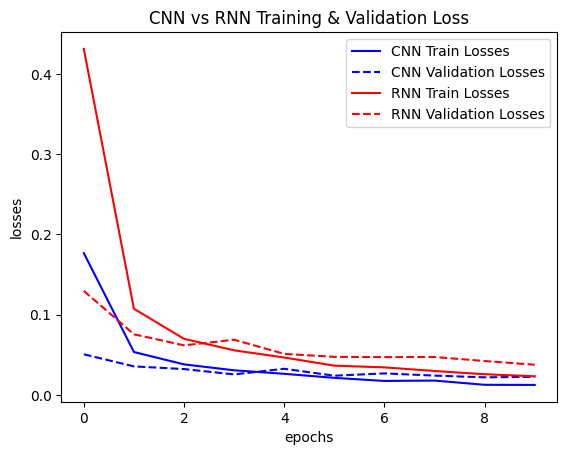

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Combine all data into the DataFrame
losses_df = pd.DataFrame({
    "CNN Train Losses": cnn_train_losses,
    "CNN Validation Losses": cnn_val_losses,
    "RNN Train Losses": rnn_train_losses,       
    "RNN Validation Losses": rnn_val_losses
})

# 2. Plot CNN lines
plt.plot(losses_df['CNN Train Losses'], label='CNN Train Losses', linestyle='-', color='blue')
plt.plot(losses_df['CNN Validation Losses'], label='CNN Validation Losses', linestyle='--', color='blue')

# 3. Plot RNN lines (using different styles/colors helps differentiate them)
plt.plot(losses_df['RNN Train Losses'], label='RNN Train Losses', linestyle='-', color='red')
plt.plot(losses_df['RNN Validation Losses'], label='RNN Validation Losses', linestyle='--', color='red')

# 4. Add chart details
plt.title("CNN vs RNN Training & Validation Loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

plt.show()
